<a href="https://colab.research.google.com/github/rsher60/LLM_Codebase/blob/main/02_langgraph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install openai langchain langgraph langchain-openai langchain-community langgraph-checkpoint-sqlite --upgrade -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 454.8/454.8 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.2/138.2 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.2/54.2 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 47.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 3.5 MB/s eta 0:00:00


In [19]:
from langgraph.graph import StateGraph
from typing import Annotated, List, Dict, Callable
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI



In [20]:
#Loading the API key
from google.colab import userdata

api_key = userdata.get('OPENAI_API_KEY')


In [21]:
class State(TypedDict):
  messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

llm = ChatOpenAI(model='gpt-4o-mini',api_key=api_key)

#defining the chatbot node




def chatbot(state: State):
  return {"messages": [llm.invoke(state["messages"])]}

def chatbot2(state: State):
  return {"messages": [llm.invoke(state["messages"])]}

#adding the node to the graph
graph_builder.add_node("chatbot",chatbot)
graph_builder.add_node("chatbot2",chatbot2)
graph_builder.add_edge("chatbot" , "chatbot2")


#setting the entry and finish points

graph_builder.set_entry_point("chatbot")
graph_builder.set_finish_point("chatbot2")

graph = graph_builder.compile()

## Visualizing the Graph

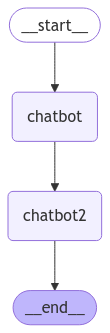

In [22]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

## Running the Chatbot

In [23]:
while True:
  user_input = input('User: ')
  if user_input.lower() in ['quit','q','exit','bye']:
    print("Goodbye!")
    break

  for event in graph.stream({'messages':('user',user_input)}):
    for value in event.values():
      print(f'Assistant: {value["messages"][-1].content}')
      print('-'*20)

User: tell me about Riddhiman sherlekar
Assistant: As of my last knowledge update in October 2021, there is no widely recognized public figure or significant information available about someone named Riddhiman Sherlekar. It's possible that he could be an emerging personality or a private individual without a significant public presence. If you are looking for information on a specific person or context related to Riddhiman Sherlekar, please provide more details, and I would be happy to help with whatever information I can.
--------------------
Assistant: As of my last knowledge update in October 2021, there is no widely recognized public figure or significant information available about someone named Riddhiman Sherlekar. It is possible that he could be an emerging personality or a private individual without a significant public presence. 

If you are looking for information on a specific person or context related to Riddhiman Sherlekar, please provide more details, and I would be happy

KeyboardInterrupt: Interrupted by user

## Tavily AI

In [24]:
!pip install -q tavily-python

In [25]:
from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv(), override=True)

False

In [27]:
from tavily import TavilyClient
import os

#initialising the tavily client
client = TavilyClient(api_key = userdata.get('TAVILY_API_KEY'))

response = client.search(query="EUFA EURO 2024 FINAL",
                         search_depth="advanced",
                         max_results=7,
                         include_images=True,
                         include_answer=True,
                         include_raw_content=False
                         )
response

{'query': 'EUFA EURO 2024 FINAL',
 'follow_up_questions': None,
 'answer': 'The UEFA Euro 2024 final was held on 14 July 2024 at the Olympiastadion in Berlin, Germany. The final match was contested by Spain and England, with Spain emerging as the champions with a 2-1 victory.',
 'images': ['https://media.gettyimages.com/id/1826603339/photo/ceremony-uefa-euro-2024-final-tournament-draw.jpg?s=1024x1024&w=gi&k=20&c=_m-YoKCI8BtPh7Tp-2xkpzJrM8ypmmDiJ30PTBcXWwM=',
  'https://editorial.uefa.com/resources/0287-1986ffeebf0e-35bc7a22edf9-1000/final_tournament_draw_pots.jpeg',
  'https://editorial.uefa.com/resources/028f-1b5654e10e48-66772edd7acc-1000/16x9_euro24_finalposter_espeng.jpeg',
  'https://media.gettyimages.com/id/1826603341/photo/ceremony-uefa-euro-2024-final-tournament-draw.jpg?s=1024x1024&w=gi&k=20&c=cECyUVOy_QMju_APuYA7AS6KpON_lvuc-KjTG9sxeUA=',
  'https://media.gettyimages.com/id/1826905146/photo/ceremony-uefa-euro-2024-final-tournament-draw.jpg?s=1024x1024&w=gi&k=20&c=PxIjjcNmHTKy

## Enhancing the chatbot with Tools

In [34]:
import os
os.environ["TAVILY_API_KEY"] = userdata.get('TAVILY_API_KEY')

In [35]:
from langchain_community.tools.tavily_search import TavilySearchResults

tool = TavilySearchResults(max_results=3)
tools = [tool]

response = tool.invoke('what is gpt o1')
response

[{'url': 'https://koluris.medium.com/how-openais-gpt-o1-model-works-what-it-means-for-you-e2f202b37ba4',
  'content': 'In September 2024, OpenAI has introduced GPT-o1, a landmark model that resets the current progression in terms of AI development.Unlike previous models, GPT-o1 is designed for "chain-of-thought" reasoning. It reasons in step sequence, so to speak, before presenting the actual answer.This helps it nail complex tasks such as problem-solving, coding, and logic-based queries.'},
 {'url': 'https://www.datacamp.com/blog/open-ai-o1',
  'content': "OpenAI o1 is a new series of models from OpenAI excelling in complex reasoning tasks, using chain-of-thought reasoning to outperform GPT-4o in areas like math, coding, and science. To showcase o1's enhanced reasoning capabilities compared to GPT-4o, OpenAI evaluated the model on a variety of challenging math, coding, and science benchmarks. While we eagerly anticipated the arrival of GPT-5, OpenAI surprised us with the introduction 

In [37]:
from langgraph.graph import StateGraph
from typing import Annotated, List , Dict, Any
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI
from langchain_community.tools.tavily_search import TavilySearchResults

In [41]:
# new import

from langgraph.prebuilt import ToolNode, tools_condition

class State(TypedDict):
  messages: Annotated[list,add_messages]

graph_builder = StateGraph(State)

tool = TavilySearchResults(max_results=3)
tools = [tool]

llm = ChatOpenAI(model_name="gpt-4o-mini", temperature=1,api_key =userdata.get('OPENAI_API_KEY') )

#tell llm which tools it can use
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
  return {"messages":[llm_with_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot",chatbot)

tool_node = ToolNode(tools=[tool])
graph_builder.add_node("tools", tool_node)
# add this
#define conditional node

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)

graph_builder.add_edge("tools","chatbot")

graph_builder.set_entry_point("chatbot")

graph = graph_builder.compile()

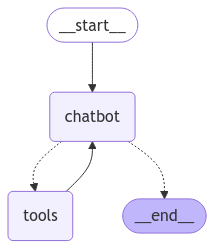

In [43]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [44]:
while True:
  user_input = input('User: ')
  if user_input.lower() in ['quit','exit','bye','q']:
    print('Goodbye!')
    break

  for event in graph.stream({'messages':('user', user_input)}):
    for value in event.values():
      print('Assistant: ', value['messages'][-1].content)
    print('-'* 50)

Assistant:  Succeeding in life is a multifaceted journey that can vary greatly from person to person. Here are some key principles that can help guide you:

1. **Set Clear Goals**: Define what success means to you and set achievable, specific goals. Break them down into smaller, manageable steps.

2. **Continuous Learning**: Commit to lifelong learning. Engage in education, read books, attend workshops, and seek new experiences.

3. **Resilience**: Develop the ability to bounce back from failures and setbacks. Resilience helps you deal with challenges and continue moving forward.

4. **Time Management**: Prioritize your tasks and manage your time effectively. Use tools and techniques to stay organized and focused.

5. **Build Relationships**: Networking and building a support system can provide you with guidance, collaboration opportunities, and emotional support.

6. **Stay Healthy**: Physical and mental health are crucial for success. Maintain a balanced diet, exercise regularly, and

KeyboardInterrupt: Interrupted by user